# Data Science Lab Winter Project 2024/2025
## Age Detection
Within the field of speech processing, a long-standing task of interest is estimating the age of a speaker based on their vocal characteristics. Some systems are capable of analyzing spoken sentences to extract features that correlate with the speaker’s age. The process of estimating a speaker’s age from their speech is referred to as age estimation. The target (output) of the system is a single value representing the estimated age of the speaker.

Report by:
- Gosmar Dario: s337625
- Maretto Chiara: s339401

# 1 Imports
## 1.1 Library Import

In [20]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1.2 Dataset Import
The dataset is comprised of 3,624 samples: 2,933 samples for the **development set** and 691 samples for the **evaluation set**. Each sample corresponds to a spoken sentence, and the associated speaker’s age is provided as the target label. 
The speech samples have been collected in controlled conditions to ensure consistent feature extraction.

For each sample, a variety of acoustic and linguistic features have been extracted from the speech signal. These features form the dataset and include:
- **sampling rate**: the sampling rate of the audio signal, in Hz
- **age**: the chronological age of the speaker (target label)
- **gender**: the gender of the speake
- **ethnicity**: the ethnicity of the speaker
- **mean pitch**, **max pitch**, **min pitch**: mean, maximum, and minimum pitch of the speech signal, in Hz
- **jitter**: a measure of the variations in pitch, representing voice stability
- **shimmer**: a measure of amplitude variations in the speech signal
- **energy**: the overall energy of the speech signal
- **zcr mean**: the mean zero-crossing rate, indicating the number of times the signal changes sign
- **spectral centroid mean**: the mean spectral centroid, representing the “center of mass” of the frequency spectrum
- **tempo**: the estimated speaking rate, in beats per minute (BPM)
- **hnr**: the harmonic-to-noise ratio, indicating voice quality
- **num words**, **num characters**: the number of words and characters in the spoken sentence
- **num pauses**: the number of pauses detected in the speech
- **silence duration**: the total duration of silence within the speech signal, in seconds
- **path**: the file path to the audio recording

In [21]:
dev_df = pd.read_csv("DSL_Winter_Project_2025/development.csv")
eval_df = pd.read_csv("DSL_Winter_Project_2025/evaluation.csv")

# 2 Data Exploration

In [22]:
dev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2933 entries, 0 to 2932
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      2933 non-null   int64  
 1   sampling_rate           2933 non-null   int64  
 2   age                     2933 non-null   float64
 3   gender                  2933 non-null   object 
 4   ethnicity               2933 non-null   object 
 5   mean_pitch              2933 non-null   float64
 6   max_pitch               2933 non-null   float64
 7   min_pitch               2933 non-null   float64
 8   jitter                  2933 non-null   float64
 9   shimmer                 2933 non-null   float64
 10  energy                  2933 non-null   float64
 11  zcr_mean                2933 non-null   float64
 12  spectral_centroid_mean  2933 non-null   float64
 13  tempo                   2933 non-null   object 
 14  hnr                     2933 non-null   

## 2.1 Outliers

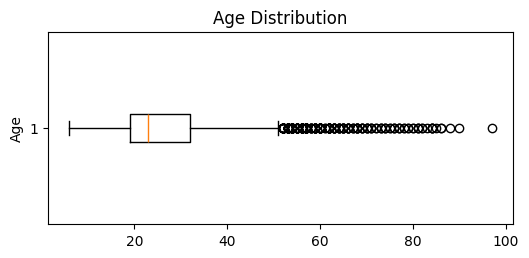

In [23]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['age'], vert = False)
plt.title('Age Distribution')
plt.ylabel('Age')
plt.show()


## 2.2 Correlation between features

In [24]:
spearman_corr = dev_df['num_words'].corr(dev_df['num_characters'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.9950099134407278


In [25]:
spearman_corr = dev_df['num_pauses'].corr(dev_df['silence_duration'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.7378261155278655


We can see that *num_words* and *num_characters* are very higly correlated. We decide to remove *num_characters* from the dataset. The same holds for *num_pauses* and *silence_duration* and we decided to keep *silence_duration*. 

In [26]:
df = dev_df.drop(columns=['num_pauses', 'num_characters'], axis=1)

In [27]:
df['tempo'] = df['tempo'].str.replace('[', '').str.replace(']', '').astype('float')
df['tempo']

0       151.999081
1       129.199219
2       117.453835
3       117.453835
4       112.347147
           ...    
2928    184.570312
2929     83.354335
2930     89.102909
2931    143.554688
2932     83.354335
Name: tempo, Length: 2933, dtype: float64

In [28]:
dev_df['gender'].unique().size, dev_df['ethnicity'].unique().size

(2, 165)

In [29]:
encoded_df = pd.get_dummies(df, columns=['gender'])

In [30]:
df_dropped = encoded_df.drop(columns=['ethnicity','path', 'Id']) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)

In [32]:
r2,mse

(0.3278958624318641, np.float64(109.63133964577658))

In [33]:
ndx = np.argsort(reg.feature_importances_)
for i, j in zip(feature_names[ndx], reg.feature_importances_[ndx]): print(i, j)

sampling_rate 0.0
num_words 0.002027401032719101
gender_female 0.005803319740858837
gender_male 0.0063977766422848425
tempo 0.048899657314993315
energy 0.05966273918225336
shimmer 0.06166356069646369
min_pitch 0.06337359447315459
mean_pitch 0.06401117883066365
max_pitch 0.06403143686838274
spectral_centroid_mean 0.07110441013198163
jitter 0.07263367120431562
hnr 0.07331254512224156
zcr_mean 0.07374570738386527
silence_duration 0.33333300137582184


Try to summarize pitch range.

In [36]:
df['pitch_range'] = df['max_pitch'] - df['min_pitch']

In [37]:
spearman_corr = df['pitch_range'].corr(df['jitter'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.3324121651517805


In [42]:
df.head()

,Id,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,silence_duration,path,pitch_range
0,0,22050,24.0,female,arabic,1821.6906,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999081,-123.999726,69,23.846893,audios_development/1.wav,3854.28634
1,1,22050,22.5,female,hungarian,1297.8187,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,69,19.388662,audios_development/2.wav,3853.48632
2,2,22050,22.0,female,portuguese,1332.8524,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,69,21.640998,audios_development/3.wav,3853.37855
3,3,22050,22.0,female,english,1430.3499,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,69,19.644127,audios_development/4.wav,3850.47017
4,4,22050,22.0,male,dutch,1688.7234,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347147,-80.349204,69,18.041905,audios_development/5.wav,3853.16358


In [40]:
df_dropped = df.drop(columns=['ethnicity','path', 'Id', 'max_pitch','min_pitch', 'mean_pitch', 'sampling_rate', 'num_words', 'gender']) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [43]:
df_dropped.head()

,age,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,silence_duration,pitch_range
0,24.0,0.013795,0.082725,0.002254,0.210093,3112.257251,151.999081,-123.999726,23.846893,3854.28634
1,22.5,0.025349,0.096242,0.007819,0.078849,1688.016389,129.199219,-86.928478,19.388662,3853.48632
2,22.0,0.019067,0.119456,0.002974,0.105365,2576.901706,117.453835,-98.450670,21.640998,3853.37855
3,22.0,0.017004,0.102389,0.022371,0.173701,3269.751413,117.453835,-56.459762,19.644127,3850.47017
4,22.0,0.028027,0.124831,0.005369,0.107279,1930.897375,112.347147,-80.349204,18.041905,3853.16358


In [41]:
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
r2,mse

(0.32370315352335344, np.float64(110.3152400544959))

In [44]:
ndx = np.argsort(reg.feature_importances_)
for i, j in zip(feature_names[ndx], reg.feature_importances_[ndx]): print(i, j)

tempo 0.060351500713464325
shimmer 0.07541906730525802
energy 0.07859089723953802
pitch_range 0.0821289858092476
hnr 0.08387637106273141
jitter 0.08446163819128046
spectral_centroid_mean 0.08950396528876076
zcr_mean 0.09533628716209573
silence_duration 0.3503312872276237


# 3 Data Preprocessing

# 4 Model Selection

# 5 Hyperparameter Tuning

# 6 Evaluation